# IT0005 — Chi-Square Feature Selection
**Member 5 — Preprocessing Technique: Chi-Square (χ²) Feature Selection**

Course: IT2011 — Artificial Intelligence and Machine Learning (SLIIT, Year 2, Semester 1)

This notebook is **fully independent**: it loads the raw dataset directly and performs its own
missing-value handling and its own encoding technique from start to finish.

## 1. Introduction

**Chi-Square feature selection** statistically tests how strongly each categorical feature is
associated with the target class, and keeps only the most informative features. This reduces
noise and dimensionality, which can speed up training and reduce overfitting risk — useful when
some features (like `veil-color` or `gill-attachment`) contribute little discriminative power
compared to a strongly predictive feature like `odor`.

## 2. Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/mushrooms.csv')
print("Shape:", df.shape)
df.head()

Shape: (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## 3. Handle Missing Values & Drop Useless Column

**Missing-value strategy chosen: mode imputation.**
Mode imputation is used so every column is complete and numeric-ready before the chi-square
test, which requires non-negative integer-like inputs.

In [2]:
df = df.replace('?', np.nan)

print("Missing value counts per column:")
print(df.isnull().sum())
print()
print("Missing value percentage per column:")
print((df.isnull().sum() / len(df) * 100).round(2))

# veil-type has only 1 unique value across the whole dataset -> no predictive
# information at all, so every member drops it after noting this.
print()
print("veil-type unique values:", df['veil-type'].unique())
df = df.drop(columns=['veil-type'])

# Strategy: mode imputation for stalk-root (chi2 test needs a complete, encoded matrix)
mode_value = df['stalk-root'].mode()[0]
print("Mode of stalk-root:", mode_value)
df['stalk-root'] = df['stalk-root'].fillna(mode_value)

print()
print("Missing values remaining:", df.isnull().sum().sum())

Missing value counts per column:
class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

Missing value percentage per column:
class                        0.00
cap-shape                    0.00
cap-surface                  0.00
cap-color                    0.00
bruises              

/var/folders/ln/lpsmr0qd3673cmmw327l0g1m0000gn/T/ipykernel_27637/3314362105.py:18: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['stalk-root'].fillna(mode_value, inplace=True)


## 4. Apply Chi-Square Feature Selection

`chi2` requires non-negative numeric input, so features are first label-encoded. `SelectKBest`
is then used to rank and select the top features against the target.

In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2

feature_cols = [c for c in df.columns if c != 'class']

df_le = df.copy()
for col in feature_cols:
    df_le[col] = LabelEncoder().fit_transform(df_le[col])
df_le['class'] = df_le['class'].map({'e': 0, 'p': 1})

X = df_le[feature_cols]
y = df_le['class']

selector = SelectKBest(score_func=chi2, k='all')
selector.fit(X, y)

scores_df = pd.DataFrame({
    'feature': feature_cols,
    'chi2_score': selector.scores_,
    'p_value': selector.pvalues_
}).sort_values('chi2_score', ascending=False).reset_index(drop=True)

print(scores_df)

                     feature   chi2_score        p_value
0                 gill-color  5957.764469   0.000000e+00
1                  ring-type  1950.610146   0.000000e+00
2                  gill-size  1636.606833   0.000000e+00
3                    bruises  1194.277352  1.069037e-261
4               gill-spacing   826.795274  8.061293e-182
5                    habitat   751.309489  2.082916e-165
6                 stalk-root   425.896927   1.270374e-94
7          spore-print-color   379.132729   1.922119e-84
8                 population   311.766736   9.002366e-70
9   stalk-surface-above-ring   222.982400   2.022392e-50
10               cap-surface   214.068544   1.779362e-48
11  stalk-surface-below-ring   206.648180   7.398869e-47
12    stalk-color-above-ring   119.792216   7.024638e-28
13    stalk-color-below-ring   109.789410   1.089740e-25
14                      odor    75.910163   2.968682e-18
15               stalk-shape    36.594105   1.454709e-09
16               ring-number   

### Choosing K

We keep every feature with a **statistically significant** association with the target
(`p_value < 0.05`) AND a chi2 score above a practical noise threshold. Inspecting the ranked
table above, scores drop off sharply after the top ~10-12 features (e.g. `odor`, `spore-print-color`,
`gill-color`, `ring-type` dominate, while `veil-color` / `gill-attachment` contribute very
little). We choose **K = 10** as a reasonable cut that keeps the strongest, most significant
features while meaningfully reducing dimensionality.

In [4]:
K = 10
top_features = scores_df.head(K)['feature'].tolist()
print(f"Top {K} selected features:")
print(top_features)

shape_before = df.shape
df = df_le[top_features + ['class']]
print()
print("Shape before selection:", shape_before)
print("Shape after selection: ", df.shape)
df.head()

Top 10 selected features:
['gill-color', 'ring-type', 'gill-size', 'bruises', 'gill-spacing', 'habitat', 'stalk-root', 'spore-print-color', 'population', 'stalk-surface-above-ring']

Shape before selection: (8124, 22)
Shape after selection:  (8124, 11)


,gill-color,ring-type,gill-size,bruises,gill-spacing,habitat,stalk-root,spore-print-color,population,stalk-surface-above-ring,class
0,4,4,1,1,0,5,2,2,3,2,1
1,4,4,0,1,0,1,1,3,2,2,0
2,5,4,0,1,0,3,1,3,2,2,0
3,5,4,1,1,0,5,2,2,3,2,1
4,4,0,0,0,1,1,2,3,0,2,0


## 5. Encode Target Variable

In [5]:
# Target was already mapped to 0/1 above (needed before the chi2 test itself),
# this cell simply confirms/repeats it per the shared notebook structure.
df['class'] = df['class'].map({0: 0, 1: 1})  # no-op, already numeric
print(df['class'].value_counts())

class
0    4208
1    3916
Name: count, dtype: int64


## 6. EDA Visualization

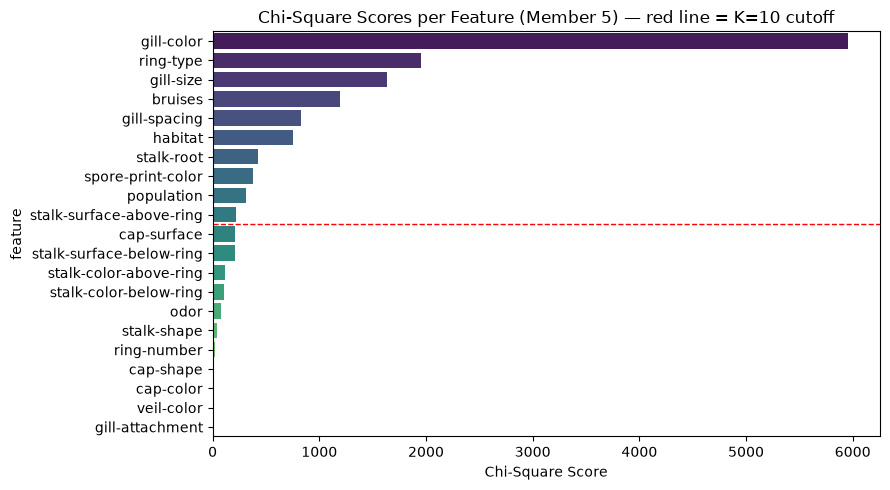

In [6]:
import os
os.makedirs('../results/eda_visualizations', exist_ok=True)

plt.figure(figsize=(9, 5))
sns.barplot(data=scores_df, x='chi2_score', y='feature',
            palette='viridis')
plt.axhline(K - 0.5, color='red', linestyle='--', linewidth=1)
plt.title('Chi-Square Scores per Feature (Member 5) — red line = K=10 cutoff')
plt.xlabel('Chi-Square Score')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/M5_chi2_selection.png', dpi=150)
plt.show()

## 7. Save Output

In [7]:
os.makedirs('../results/outputs', exist_ok=True)
df.to_csv('../results/outputs/step_M5_chi2_selected.csv', index=False)
print("Saved: ../results/outputs/step_M5_chi2_selected.csv")
print("Final shape:", df.shape)

Saved: ../results/outputs/step_M5_chi2_selected.csv
Final shape: (8124, 11)
